# Horse racing data analysis

Before proceeding with the main tasks, make sure to complete the initial setting by running the following code.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from package import algorithm


rc('text', usetex=True)
rc('font', family='serif')
sz = 36

file_name = 'runs.csv'
processed_data = 'runs(preprocessing).csv'
CV_filename = 'cross_validation.txt'

current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'horse racing data' + '\\' 
image_path = current_path + '\\' + 'image' + '\\' + 'horse racing' + '\\' 

name_columns = 'Horse'
covariate_columns = ['Act. Wt.','Dr.','Win Odds']
d = len(covariate_columns)

## Data preprocessing

If the file 'tennis(preprocessed).csv' is already present within the folder 'data/tennis', then you have the option to skip this particular module.

Drop Nan

In [3]:
df = pd.read_csv(data_path + file_name,index_col='race_id')
NaN_columns = covariate_columns+['Pla.']
for covariate in NaN_columns:
    df[covariate] = pd.to_numeric(df[covariate], errors='coerce')
    df = df.dropna(subset=[covariate])


Select suitable matches and players

In [4]:
def delete_matches(df,m_lower=0,m_upper=100):
    df = df.copy()
    i = 0
    indexes = []
    for index in df.index.unique():
        m = df[df.index == index].shape[0]
        if m >= m_lower and m <= m_upper:
            i += 1
        else:
            indexes.append(index)
    df = df.drop(index = indexes)
    return df,i

def delete_players(df,d_min=0,name = 'Horse'):
    counts = df[name].value_counts()
    values_to_keep = counts[counts >= d_min].index
    df = df[df[name].isin(values_to_keep)]
    return df,len(values_to_keep)

def select(df,m_lower=0,m_upper=100,d_min=0,name = 'Horse'):
    NN = len(df.index.unique())
    nn = len(df[name].value_counts())
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of horses: {nn}')
        df,N = delete_matches(df,m_lower,m_upper)
        df,n = delete_players(df,d_min)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N

In [5]:
m_lower = 4
m_upper = 14
d_min = 10
df,n,N = select(df,m_lower,m_upper,d_min)

----------
The number of matches: 6348
The number of horses: 4405
----------
The number of matches: 6348
The number of horses: 2817
----------
The number of matches: 6328
The number of horses: 2814


Normalization

In [6]:
# Actual Weight
df['Act. Wt.'] = np.log(df['Act. Wt.'])
mean_A = df['Act. Wt.'].mean()
std_A = df['Act. Wt.'].std()
df['Act. Wt.'] = (df['Act. Wt.'] - mean_A) / std_A
# Draw
df['Dr.'] = df['Dr.'].astype(float)
for index in df.index.unique():
    df.loc[index,'Dr.'] = pd.Series(df.loc[index,'Dr.']/max(df.loc[index,'Dr.']))
# Belief
for index in df.index.unique():
    t = 1/df.loc[index,'Win Odds']
    df.loc[index,'Win Odds'] = np.log(t / np.sum(t))

In [7]:
df.to_csv(data_path+processed_data)

## Data Analysis

### Loading data

Load the preprocessed tennis data that is located in the 'tennis(preprocessed).csv' file.

Construct T and X

In [8]:
df = pd.read_csv(data_path + processed_data,index_col='race_id',low_memory=False)

horseID = {}
T = []
cov = []
for index in df.index.unique():
    temp = df.loc[index].sort_values(by='Pla.')    

    ### covariates
    x = np.array(temp[covariate_columns])
    cov.append(x)
    place = np.array(temp['Pla.'])
    
    ###
    t = []
    horses_name = temp[name_columns].tolist()
    for i,horse_name in enumerate(horses_name):
        added_horse = horseID.keys()
        if horse_name in added_horse:
            horseID[horse_name]['times'] += 1
        else:
            n = len(added_horse)
            horseID[horse_name] = {'ID':n,'times':1,'place':[],'covariate':[]}
        #horseID[horse_name]['place'].append(i+1)
        horseID[horse_name]['place'].append(place[i])
        xx = x[i].copy()
        xx[-1] = np.exp(xx[-1])
        horseID[horse_name]['covariate'].append(xx)
        t.append(horseID[horse_name]['ID'])
    T.append(t)
n = len(horseID)
N = len(T)

### Fit PlusDC and PL

PlusDC

In [10]:
u_plusDC,v_plusDC = algorithm.AM(T,cov,n,d,
                                 E=1e-5,Eu=1e-5,Ev=1e-12,
                                 I=52,detail=True)
l_plusDC = algorithm.multi_likelihood(T,cov,u_plusDC,v_plusDC)

-----1-----
log-likelihood: -18.859192620619336
v iteration times: 6 and v = [-0.02473556 -0.09376191  0.5810856 ]
u iteration times: 52
-----2-----
log-likelihood: -17.037245968275066
v iteration times: 5 and v = [-0.096561   -0.15920727  0.53608646]
u iteration times: 52
-----3-----
log-likelihood: -16.99292532905669
v iteration times: 5 and v = [-0.12270102 -0.17647121  0.51603965]
u iteration times: 52
-----4-----
log-likelihood: -16.986257972657747
v iteration times: 4 and v = [-0.13252882 -0.18302773  0.50772327]
u iteration times: 52
-----5-----
log-likelihood: -16.98523852042528
v iteration times: 4 and v = [-0.13629298 -0.18565049  0.50436725]
u iteration times: 42
-----6-----
log-likelihood: -16.98508212086962
v iteration times: 4 and v = [-0.13774407 -0.18669121  0.50303681]
u iteration times: 32
-----7-----
log-likelihood: -16.985058156877734
v iteration times: 4 and v = [-0.13830596 -0.18710116  0.50251318]
u iteration times: 22


In [12]:
likelihood = algorithm.multi_likelihood(T,cov,u_plusDC,v_plusDC)
print(f"coefficient:{v_plusDC}")
print(f"log-likelihood:{likelihood}")

coefficient:[-0.13830596 -0.18710116  0.50251318]
log-likelihood:-16.985054453602885


In [11]:
import itertools
from joblib import Parallel, delayed
# models
def get_results(T,cov,s,N,n):
    X = [x[:,s] for x in cov]
    d = len(s)
    u_plusDC,v_plusDC = algorithm.AM(T,X,n,d,
                                 E=1e-5,Eu=1e-5,Ev=1e-12,
                                 I=52)
    likelihood = algorithm.multi_likelihood(T,X,u_plusDC,v_plusDC)
    AIC = (n-1+d) * 2 / N - 2 * likelihood
    BIC = (n-1+d) * np.log(N) / N - 2 * likelihood
    print(f'{s}:{likelihood},{AIC},{BIC}')
    return [s,likelihood,AIC,BIC]
    

# get_subset
get_subset = lambda n: [subset for i in range(n + 1)
                         for subset in itertools.combinations(list(range(n)), i)]
subset = get_subset(10)
results = Parallel(n_jobs=8)(delayed(get_results)(T,cov,ss,N,n) for ss in subset)

In [16]:
for result in results:
    t = [0,0,0]
    for s in result[0]:
        t[s] = 1
    string = f'subset:{t}, log-likelihood:{result[1]}, AIC:{result[2]},BIC:{result[3]}'
    print(string)

subset:[0, 0, 0], log-likelihood:-17.67061983418555, AIC:36.23030414371876,BIC:39.23211454828194
subset:[1, 0, 0], log-likelihood:-17.649590370686397, AIC:36.18856127234625,BIC:39.191438797565155
subset:[0, 1, 0], log-likelihood:-17.594086950955738, AIC:36.07755443288493,BIC:39.08043195810383
subset:[0, 0, 1], log-likelihood:-17.04559241363931, AIC:34.98056535825207,BIC:37.98344288347097
subset:[1, 1, 0], log-likelihood:-17.573323596330756, AIC:36.036343779260754,BIC:39.04028842513539
subset:[1, 0, 1], log-likelihood:-16.995941004402972, AIC:34.88157859540519,BIC:37.88552324127982
subset:[0, 1, 1], log-likelihood:-17.03343892267375, AIC:34.95657443194674,BIC:37.960519077821374
subset:[1, 1, 1], log-likelihood:-16.985054453602885, AIC:34.8601215494308,BIC:37.86513331596117


PL

In [17]:
u_pl,v_pl = algorithm.AM(T,cov,n,d,P=True,Eu=1e-5,detail=True)
l_pl = algorithm.multi_likelihood(T,cov,u_pl,v_pl)

In [18]:
sorted_indices = np.argsort(-u_pl)  
ranks_pl = np.empty_like(sorted_indices)
ranks_pl[sorted_indices] = np.arange(1, len(u_pl) + 1) 

In [20]:
plusDC_top10 = np.argsort(u_plusDC)[-10:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
i = 0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value['ID'] == index][0]
    id = horseID[horse_name]['ID']
    times = horseID[horse_name]['times']
    mean_place = np.mean(horseID[horse_name]['place'])
    mean_covariate = np.mean(horseID[horse_name]['covariate'],axis=0)
    uu_pl = u_pl[id]
    print('-'*10+f'Ranking:{i}'+'-'*10)
    print(f'Horse:{horse_name}')
    print(f'Race:{times}, Mean_Place:{mean_place}')
    print(f'Mean_covariate:{mean_covariate}')
    print(f'Score_PL:{uu_pl},Score_PlusDC:{uu}, Ranking_PL:{ranks_pl[id]}\n')


----------Ranking:1----------
Horse:564
Race:11, Mean_Place:1.3636363636363635
Mean_covariate:[0.63648981 0.50649351 0.40458569]
Score_PL:4.344367506488301,Score_PlusDC:3.3001139071259775, Ranking_PL:4

----------Ranking:2----------
Horse:1033
Race:21, Mean_Place:1.9523809523809523
Mean_covariate:[0.52825318 0.67821002 0.45061126]
Score_PL:4.808684852982008,Score_PlusDC:3.0373141274900464, Ranking_PL:1

----------Ranking:3----------
Horse:2402
Race:14, Mean_Place:2.0
Mean_covariate:[0.44559995 0.54868068 0.30865071]
Score_PL:4.589571817514721,Score_PlusDC:2.9499115341331326, Ranking_PL:2

----------Ranking:4----------
Horse:1588
Race:12, Mean_Place:3.0833333333333335
Mean_covariate:[0.18942195 0.47140822 0.34202692]
Score_PL:4.499923679534747,Score_PlusDC:2.730634411575026, Ranking_PL:3

----------Ranking:5----------
Horse:160
Race:11, Mean_Place:3.1818181818181817
Mean_covariate:[0.0152958  0.51695628 0.24704135]
Score_PL:3.7775723922600735,Score_PlusDC:2.5800777878108265, Ranking_PL:

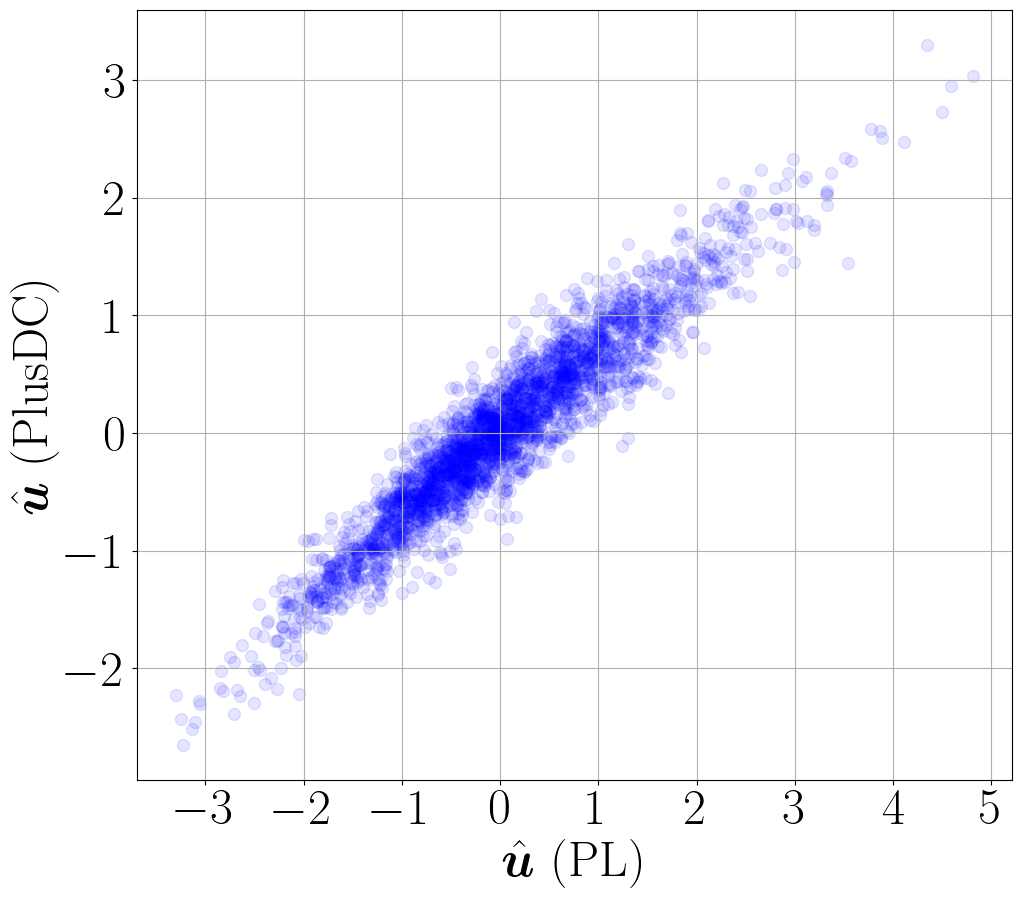

In [23]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

fig,ax = plt.subplots(figsize=(11.3,10))
ax.scatter(u_pl,u_plusDC,s = 75,alpha=0.1,c='blue')
sz = 36
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')
plt.grid()
ax.set_xlabel(r'$\hat{\bm{u}}$'+" (PL)",size = sz)
ax.set_ylabel(r'$\hat{\bm{u}}$'+" (PlusDC)",size = sz)

plt.savefig(image_path+'score.pdf')
plt.show()

### $k$-folder Cross Validation

#### 63-folder Cross Validation

In [25]:
folders = []
np.random.seed(42)
temp_folder = set(range(N))
I = int(N/100)
for i in range(I):
    temp_folder = list(temp_folder)
    index = np.random.choice(temp_folder, 100,replace=False)
    index = np.sort(index)[::-1]
    temp_folder = set(temp_folder) - set(index)
    folders.append(index.tolist())
folders[-1] = folders[-1] +list(temp_folder)

In [28]:
results = Parallel(n_jobs=8)(delayed(algorithm.horse_cross_validation)
                             (T,cov,n,d,folder,data_path,CV_filename) for folder in folders)

#### Visualization

In [29]:
Data = []
with open(data_path+CV_filename,'r') as file:
    for line in file:
        tem = np.zeros((3,3))
        models = line.split(';')[:-1]
        for i in range(3):
            tem[i,:] = list(map(float,models[i].split(',')[:-1]))
        Data.append(tem)
Data = np.array(Data)

In [30]:
np.mean(Data[:,:,2],axis=0)

array([-6.10276557, -6.51865676, -6.06798299])

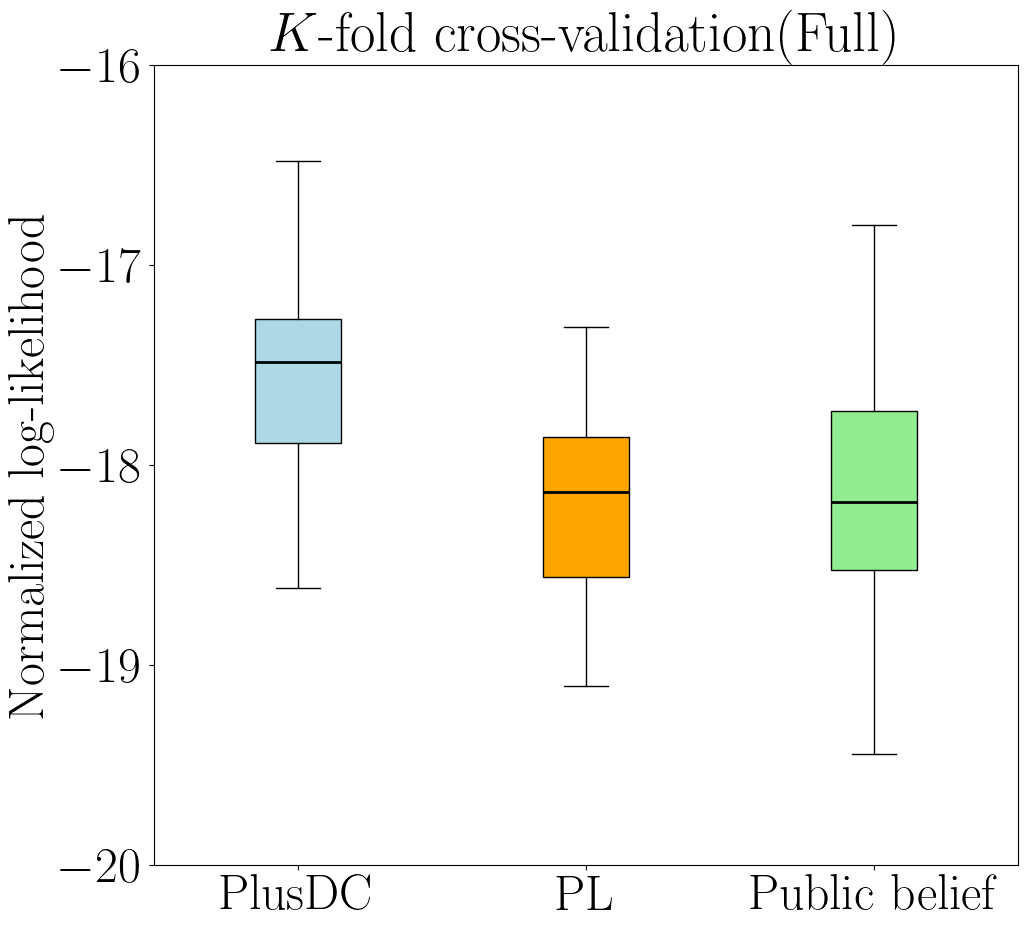

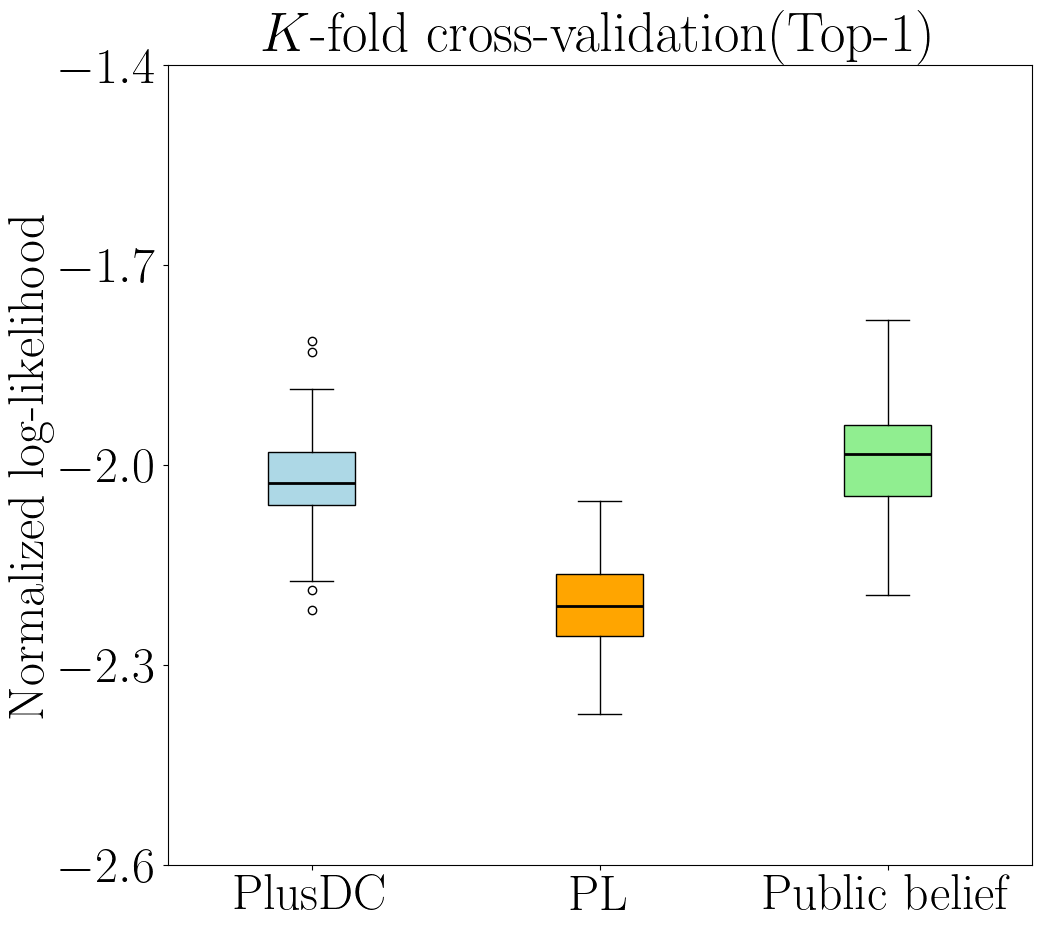

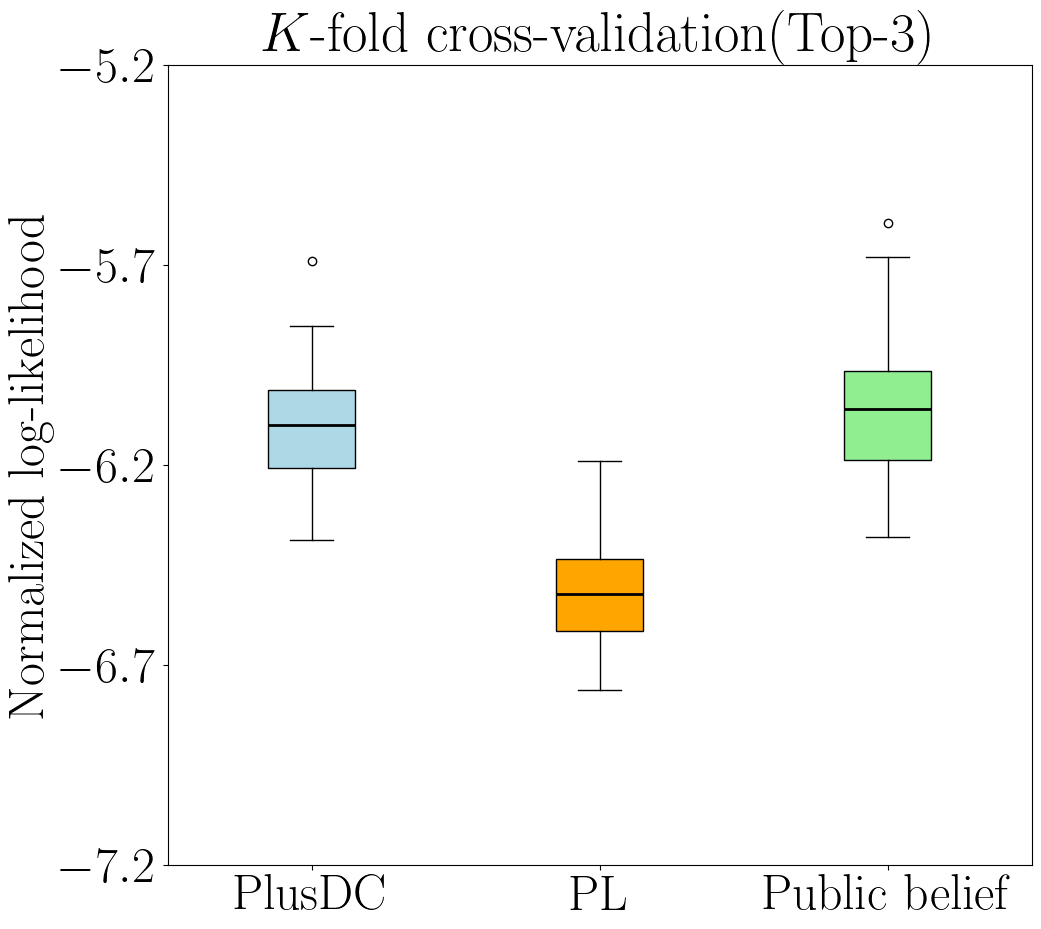

In [31]:

save_name = ['full','1','3']
title = ['(Full)', '(Top-1)', '(Top-3)']
label = ['PlusDC', 'PL', 'Public belief']
colors = ['lightblue', 'orange', 'lightgreen']
yrange = [[-20,-19,-18,-17,-16],[-1.4,-1.7,-2.0,-2.3,-2.6],[-5.2,-5.7,-6.2,-6.7,-7.2]]


for j in range(3):
    fig, ax = plt.subplots(figsize=(10.8, 10))
    bx = ax.boxplot(Data[:,:,j], tick_labels=label, patch_artist=True,medianprops={'linewidth': 2})
    ax.set_position([0.165, 0.125, 0.8, 0.8])
    ax.set_ylabel('Normalized log-likelihood',size = sz)
    plt.title('$K$-fold cross-validation'+title[j],size =sz+4)
    plt.xticks(size=sz)
    plt.yticks(yrange[j],size=sz)
    ax.tick_params(axis='y', which='both')


    for median in bx['medians']:
        median.set_color('black')
    for patch, color in zip(bx['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    plt.savefig(image_path+f'KFCV{save_name[j]}.pdf')
    plt.show()